# Figure 6 — Cross-City Generalization (BLOCKED)

**Claim (intended)**: climate, urban form and mobility structure explain when dynamic
optimization offers the greatest advantage.

**This entire figure is BLOCKED.** It depends directly on Figure 5's optimization output
(never executed) and on completed v2 thermal data for enough cities to support cross-city
statistics (currently only Palma is fully validated; Bilbao/Sevilla Phase 2 in progress at
notebook build time). Documented here, not fabricated.


In [1]:

import sys, json
from pathlib import Path
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "configs").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "src"))
sys.path.insert(0, str(REPO_ROOT / "notebooks" / "paper_figures"))
import pandas as pd, matplotlib.pyplot as plt
from plotting_utils import set_nature_style, new_panel_fig, blocked_panel, save_panel, save_source_table
set_nature_style()
FIG_DIR = REPO_ROOT / "figures/paper/main/figure6"; TAB_DIR = REPO_ROOT / "reports/paper_figures/figure6"
FIG_DIR.mkdir(parents=True, exist_ok=True); TAB_DIR.mkdir(parents=True, exist_ok=True)


## Audit — cities with complete v2 thermal data (canopy fusion + building shadow + four-state)

In [2]:

rows = []
for city in ["palma_de_mallorca","zaragoza","murcia","valladolid","a_coruna","cordoba",
             "granada","bilbao","sevilla","valencia","madrid","barcelona"]:
    canopy_v2 = (REPO_ROOT / f"data/{city}/green_mobility/thermal/canopy_fraction_v2.parquet").exists()
    building_shadow = (REPO_ROOT / f"data/{city}/green_mobility/thermal/building_shadow").exists()
    four_state = city == "palma_de_mallorca"  # only Palma has a completed four-state decomposition at notebook build time
    rows.append({"city": city, "canopy_v2": canopy_v2, "building_shadow": building_shadow, "four_state_decomposition": four_state})
df = pd.DataFrame(rows)
print(df.to_string(index=False))
n_complete = df[["canopy_v2","building_shadow","four_state_decomposition"]].all(axis=1).sum()
print(f"\ncities with FULLY complete v2 pipeline: {n_complete} -- cross-city statistics need several more to be meaningful")
save_source_table(df, TAB_DIR, "audit")


             city  canopy_v2  building_shadow  four_state_decomposition
palma_de_mallorca       True             True                      True
         zaragoza      False            False                     False
           murcia      False            False                     False
       valladolid      False            False                     False
         a_coruna      False            False                     False
          cordoba      False            False                     False
          granada      False            False                     False
           bilbao       True             True                     False
          sevilla       True             True                     False
         valencia      False            False                     False
           madrid      False            False                     False
        barcelona      False            False                     False

cities with FULLY complete v2 pipeline: 1 -- cross-city statist

## All 4 panels: BLOCKED

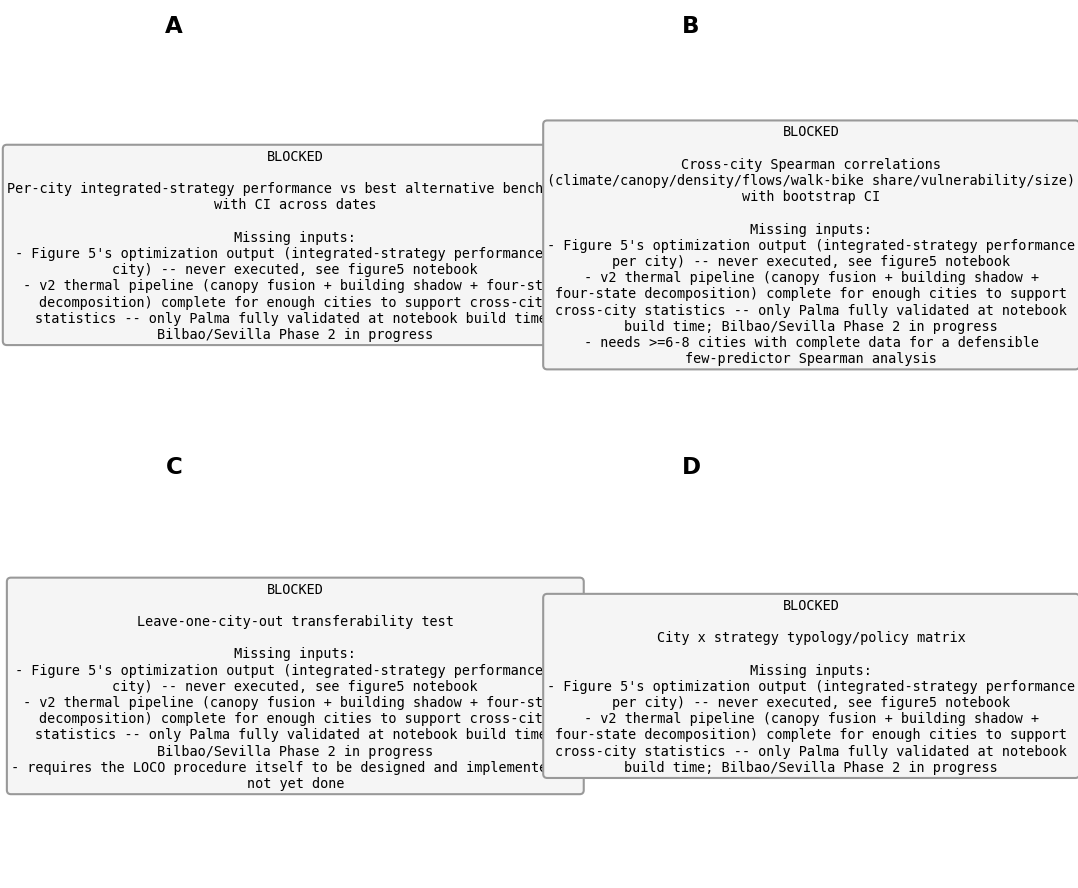

{'figure': 'figure6_cross_city_generalization', 'status': 'BLOCKED (all panels)', 'reason': 'depends on Figure 5 optimization (never executed) and multi-city v2 completeness (only Palma ready)', 'panel_a': {'status': 'BLOCKED'}, 'panel_b': {'status': 'BLOCKED'}, 'panel_c': {'status': 'BLOCKED'}, 'panel_d': {'status': 'BLOCKED'}}


In [3]:

missing_common = [
    "Figure 5's optimization output (integrated-strategy performance per city) -- never executed, see figure5 notebook",
    "v2 thermal pipeline (canopy fusion + building shadow + four-state decomposition) complete for "
    "enough cities to support cross-city statistics -- only Palma fully validated at notebook build "
    "time; Bilbao/Sevilla Phase 2 in progress",
]
panel_specs = [
    ("A", "Per-city integrated-strategy performance vs best alternative benchmark, with CI across dates", missing_common),
    ("B", "Cross-city Spearman correlations (climate/canopy/density/flows/walk-bike share/vulnerability/size) with bootstrap CI",
     missing_common + ["needs >=6-8 cities with complete data for a defensible few-predictor Spearman analysis"]),
    ("C", "Leave-one-city-out transferability test", missing_common + ["requires the LOCO procedure itself to be designed and implemented -- not yet done"]),
    ("D", "City x strategy typology/policy matrix", missing_common),
]
fig, axes = plt.subplots(2, 2, figsize=(7.0, 6.0))
for ax, (letter, reason, missing) in zip(axes.flatten(), panel_specs):
    blocked_panel(ax, letter, reason, missing)
fig.tight_layout()
fig.savefig(FIG_DIR / "figure6_composite.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "figure6_composite.png", bbox_inches="tight", dpi=300)
for ax, (letter, reason, missing) in zip(axes.flatten(), panel_specs):
    single_fig, single_ax = new_panel_fig(3.5, 3.0)
    blocked_panel(single_ax, letter, reason, missing)
    save_panel(single_fig, FIG_DIR, f"panel_{letter.lower()}")
    plt.close(single_fig)
plt.show()

manifest = {"figure": "figure6_cross_city_generalization", "status": "BLOCKED (all panels)",
            "reason": "depends on Figure 5 optimization (never executed) and multi-city v2 completeness (only Palma ready)",
            "panel_a": {"status": "BLOCKED"}, "panel_b": {"status": "BLOCKED"},
            "panel_c": {"status": "BLOCKED"}, "panel_d": {"status": "BLOCKED"}}
(TAB_DIR/"manifest.json").write_text(json.dumps(manifest, indent=2))
print(manifest)
